In [1]:
!pip install datasets
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
import json

with open("liza.json", "r") as file:
    data = json.load(file)

print(data)

{'name': 'Liza', 'age': 24, 'city': 'London', 'skills': ['Python', 'Jupyter', 'VS Code']}


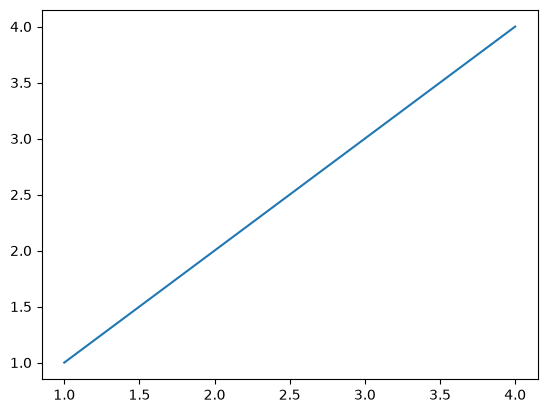

In [3]:
x = [1, 2, 3, 4]
y = [1, 2, 3, 4]
plt.plot(x, y)
plt.show()

In [4]:
df.job_posted_date.head()

0   2023-06-16 13:44:15
1   2023-01-14 13:18:07
2   2023-10-10 13:14:55
3   2023-07-04 13:01:41
4   2023-08-07 14:29:36
Name: job_posted_date, dtype: datetime64[us]

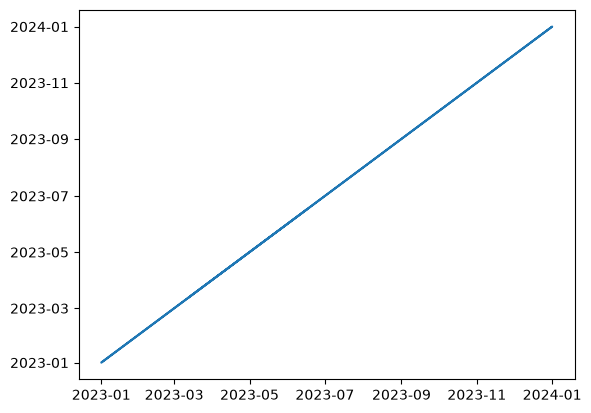

In [5]:
plt.plot(df.job_posted_date, df.job_posted_date)

In [6]:
date_counts = df.job_posted_date.value_counts()
date_counts = date_counts.sort_index()

In [7]:
date_counts

job_posted_date
2023-01-01 00:00:04    1
2023-01-01 00:00:07    1
2023-01-01 00:00:22    1
2023-01-01 00:00:24    1
2023-01-01 00:00:27    1
                      ..
2023-12-31 23:40:18    2
2023-12-31 23:40:22    2
2023-12-31 23:40:31    2
2023-12-31 23:40:32    1
2023-12-31 23:59:58    2
Name: count, Length: 607192, dtype: int64

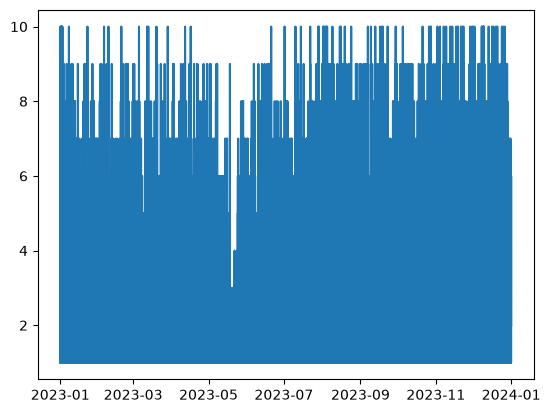

In [8]:
plt.plot(date_counts.index, date_counts)

In [9]:
df['job_posted_month'] = df['job_posted_date'].dt.month  


In [10]:
monthly_counts = df.job_posted_month.value_counts()

monthly_counts = monthly_counts.sort_index()

monthly_counts

job_posted_month
1     91822
2     64578
3     64084
4     62919
5     52104
6     61572
7     63777
8     75162
9     62359
10    66611
11    64450
12    56303
Name: count, dtype: int64

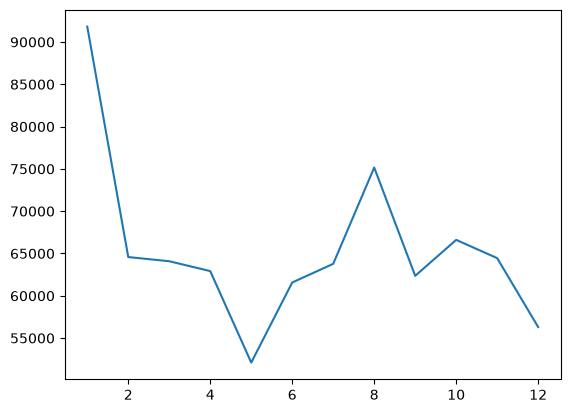

In [11]:
plt.plot(monthly_counts.index, monthly_counts.values)

In [12]:
series =pd.Series([10, 20, 30, 40, 50], index=['a', 'b', 'c', 'd', 'e'])

In [13]:
series.values

array([10, 20, 30, 40, 50])

In [14]:
job_counts =df.job_title_short.value_counts()

<BarContainer object of 10 artists>

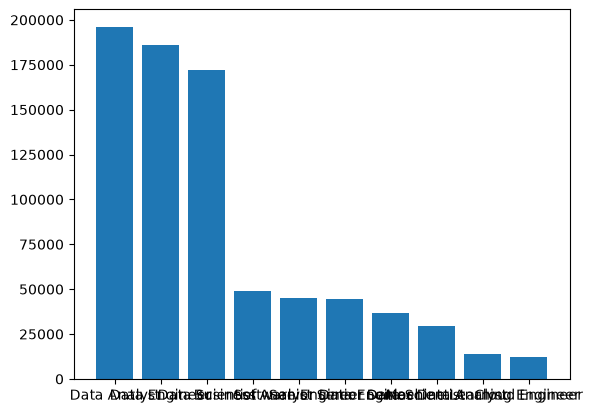

In [15]:
plt.bar(job_counts.index, job_counts.values)

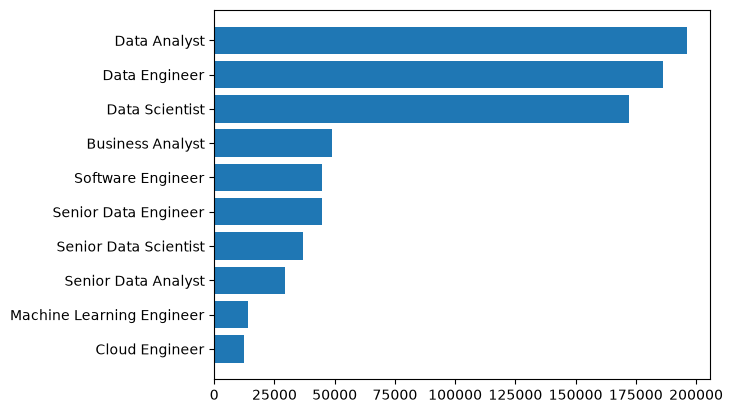

In [16]:
job_counts = job_counts.sort_values(ascending=True)
plt.barh(job_counts.index, job_counts.values)
plt.show()


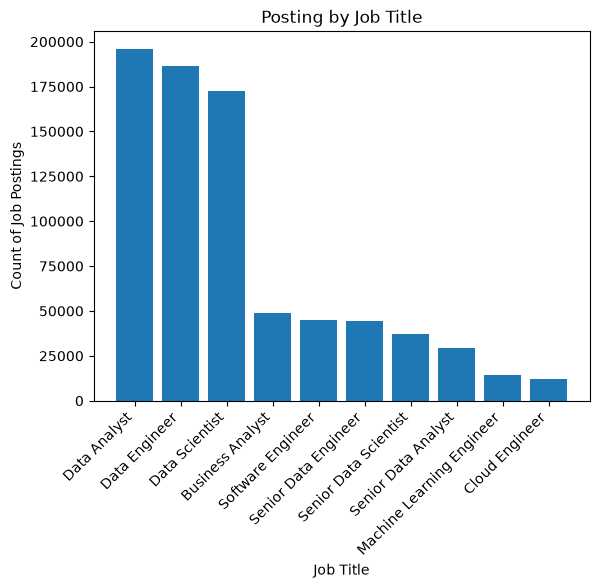

In [17]:
job_counts = job_counts.sort_values(ascending=False)
plt.bar(job_counts.index, job_counts.values)
plt.title('Posting by Job Title')
plt.ylabel('Count of Job Postings')
plt.xlabel('Job Title')
plt.xticks(rotation=45, ha='right')
plt.show()

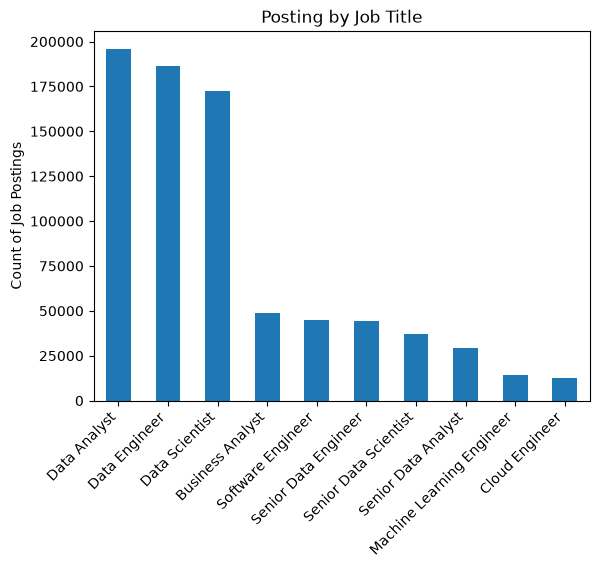

In [18]:
job_counts.plot(kind= 'bar')
plt.title('Posting by Job Title')
plt.ylabel('Count of Job Postings')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.show()

In [24]:
df[['job_posted_date', 'salary_year_avg']].dropna(subset=['salary_year_avg']) 

,job_posted_date,salary_year_avg
28,2023-08-01 13:37:57,109500.0
77,2023-06-26 14:22:54,140000.0
92,2023-02-21 13:29:59,120000.0
100,2023-07-31 13:01:18,228222.0
109,2023-10-12 13:02:19,89000.0
...,...,...
785624,2023-08-31 06:02:16,139216.0
785641,2023-01-04 16:36:07,150000.0
785648,2023-04-12 06:02:51,221875.0
785682,2023-03-04 06:16:08,157500.0


<Axes: xlabel='job_posted_date', ylabel='salary_year_avg'>

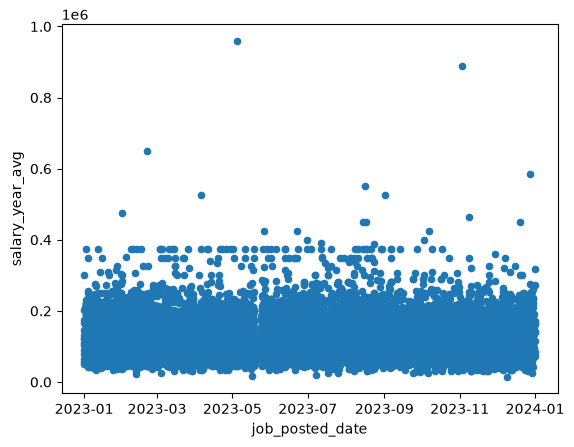

In [20]:
df.plot(x='job_posted_date', y='salary_year_avg', kind='scatter')

In [21]:
job_salary =df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

In [22]:
df.groupby('job_title_short')['salary_year_avg'].mean().sort_values()

job_title_short
Business Analyst              91082.612833
Data Analyst                  93841.907854
Cloud Engineer               111268.453846
Software Engineer            113393.760054
Senior Data Analyst          113911.363665
Machine Learning Engineer    126774.315972
Data Engineer                130125.604250
Data Scientist               135988.837171
Senior Data Engineer         145840.611624
Senior Data Scientist        154206.292996
Name: salary_year_avg, dtype: float64

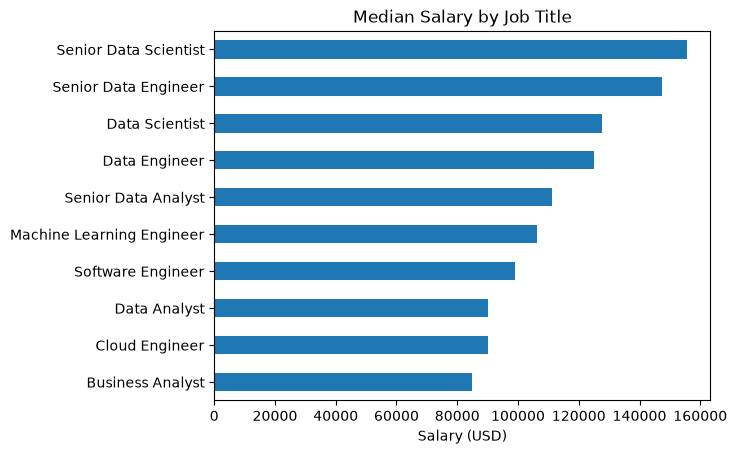

In [23]:
job_salary.plot(kind= 'barh')
plt.xlabel('Salary (USD)')
plt.ylabel('')
plt.title('Median Salary by Job Title')
plt.show()